
<center><font size=10>Health Insurance Premium Prediction</center></font>


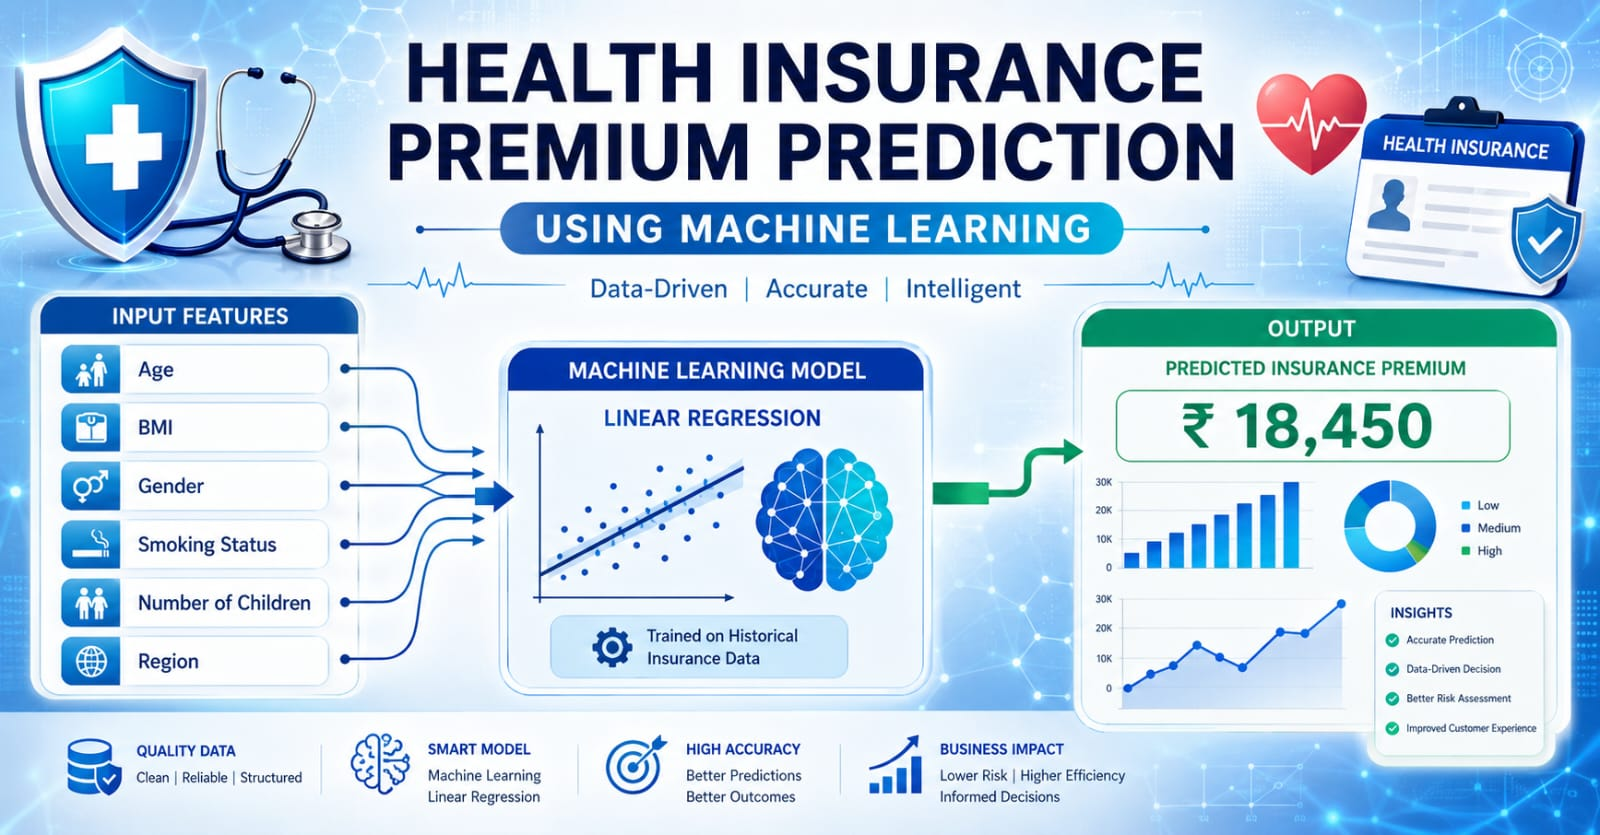

# **Problem Statement**

#**Business Context**

* Healthcare costs are increasing, and many people need affordable health
insurance. Insurance companies must decide the right premium for each customer based on factors such as age, BMI, smoking status, and other personal details.
 * Predicting the premium accurately helps companies provide fair pricing,reduce
financial risk, and improve customer satisfaction. Machine learning can analyze customer data and predict the premium more accurately, helping insurance companies make better pricing decisions.


# **Objective**

The objective of this project is to develop a machine learning model that predicts health insurance premiums based on customer information such as age, BMI, smoking status, and other personal details. The model helps insurance companies make accurate, data-driven pricing decisions.

The process includes:

* Collecting and
preprocessing customer data.
* Selecting important features such as age, BMI, and smoking status.
* Building a Linear Regression model to predict insurance premiums.
* Evaluating the model using Mean Squared Error (MSE) and R-squared (R²) to measure its accuracy.

The predicted results help insurance companies:

* Set fair and accurate premiums.
* Identify customer risk levels.
* Improve pricing strategies.
* Increase customer satisfaction and business performance.

# **Data Description**


The dataset consists of several key attributes:

- **Age**: Numerical value representing the age of the insured individual.
- **Sex**: Categorical variable indicating gender (male or female).
- **BMI**: Numerical value reflecting the Body Mass Index, a measure of body fat based on height and weight.
- **Children**: Numerical value representing the number of dependent children covered by the insurance policy.
- **Smoker**: Categorical variable indicating whether the individual is a smoker (yes or no).
- **Region**: Categorical variable that identifies the geographic area of the insured (southwest, southeast, northwest, northeast).
- **Charges**: Numerical value indicating the annual insurance premium (in USD) incurred by the policyholder.

This dataset contains a diverse range of cases, facilitating the modeling of different demographic and health profiles to predict insurance charges effectively.

# **Installing and Importing Necessary Libraries**

These libraries help with data manipulation, visualization, model building, and evaluation:

- **NumPy** and **Pandas** for efficient numerical and data manipulation.
- **Matplotlib** and **Seaborn** for insightful data visualizations.
- **Scikit-learn** for building and evaluating machine learning models.
- Additional libraries as needed for preprocessing and tuning.




In [51]:
# Mount Google Drive to access files stored in your Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **Loading the Data**

 The dataset contains customer information such as age, gender, BMI, number of children, smoking status, region, and the corresponding insurance premium (charges).

We use the Pandas library to load the dataset because it makes it easy to read, organize, and analyze tabular data.


- The dataset file is named **`insurance_prediction`**.



In [53]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/Gen AI/Dataset/insurance_prediction.csv')


# **Data Overview**


During the data overview, we:

* Check the number of rows and columns.
* View the first few records of the dataset.
* Identify the data type of each feature.
* Check for missing values or incorrect data.

This step helps us understand the dataset and prepare it for preprocessing and model training.


In [54]:
data.shape

(1338, 7)

The dataset consists of 1,338 rows and 7 columns

In [55]:
print(data.head(10))


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692


**Note:**  If the data is not displayed in a table format, remove the `print()` statement. For example, replace `print(df.head(10))` with `df.head(10)` to display the output as a table.


In [56]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [57]:
data.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [58]:
data.info()  # Shows the structure of the dataset (columns, data types, non-null values, and memory usage)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **7 columns** and **1338 rows**, with **no missing values**.
- Data types are as expected:  
  - **Numeric:** `age`, `bmi`, `children`, `charges`  
  - **Categorical:** `sex`, `smoker`, `region`

We conclude there are no missing rows in the DataFrame as all columns have 1338 non-null entries, matching the total number of records.

In [59]:
data.describe() # Displays summary statistics of the numerical columns


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [60]:
data.describe().T # Displays the statistical summary of the dataset in a transposed (row-wise) format


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Observations:**

**Age**

* The average age is **39.21 years**.
* Customers are between **18 and 64 years**, covering a wide range of adult age groups.

**BMI**

* The average BMI is **30.66**.
* This indicates that many customers are overweight or obese, which may increase insurance costs.

**Children**

* Customers have an average of **1.09 children**.
* Most customers have **0 to 2 children**.

**Insurance Charges**

* The average insurance charge is **13,270.42**.
* Insurance charges vary widely (**1,121.87 to 63,770.43**).
* The high standard deviation indicates a large variation in premiums among customers.

**Categorical Features**

* This summary covers only numerical features.
* The categorical features (**sex, smoker, and region**) will be analyzed separately to understand their effect on insurance charges.


In [61]:
data.describe(include='object') # Shows the summary of categorical features


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### Categorical Feature Insights

* **Gender:** The dataset is nearly balanced, with **males (676)** slightly more than females.
* **Smoking Status:** Most customers are **non-smokers (1064)**, while smokers are fewer.
* **Region:** The **Southeast** region has the highest number of customers (**364**), making it the most represented region in the dataset.


In [62]:
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
duplicate_rows


Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [63]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (1337, 7)


There were originally 1,338 rows. After removing 1 duplicate record, the dataset now contains 1,337 records.

# **Exploratory Data Analysis**


Exploratory Data Analysis (EDA) helps us understand the dataset by identifying patterns, trends, and relationships between features.

In this section, we will:

* Analyze the distribution of numerical features (**age, BMI, and charges**).
* Analyze the distribution of categorical features (**sex, smoker, region, and children**).
* Identify the factors that influence **insurance charges**.

EDA helps us understand the data better before building the machine learning model.


## **Univariate Analysis**

Analyzing individual features to understand their distributions.

###Distributions of Numerical Distribution

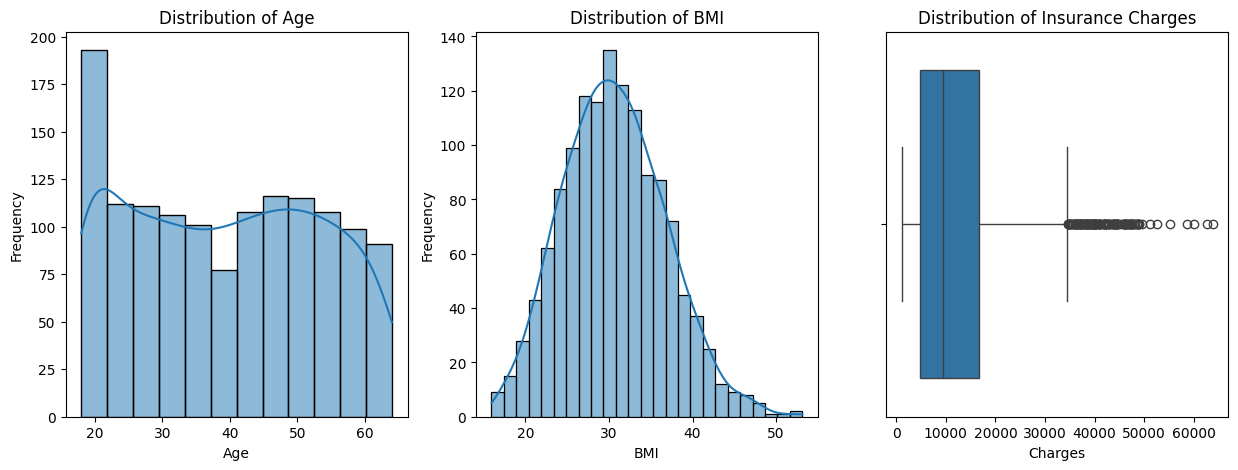

In [64]:
plt.figure(figsize=(15, 5))

# Distribution of 'age'
plt.subplot(1, 3, 1)
sns.histplot(data['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Distribution of 'bmi'
plt.subplot(1, 3, 2)
sns.histplot(data['bmi'], kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

# Distribution of 'charges'
plt.subplot(1, 3, 3)
sns.boxplot(x='charges', data=data)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()


### Observations from Numerical Distributions:
* **Age:** The distribution of age is **higher number of individuals in the lower age brackets** — particularly those around **20 to 25 years old**.
This suggests that **younger individuals may be more aware of** or have greater access to **insurance** options.

*   **BMI:** Most customers have a BMI around 30.
The distribution is slightly right-skewed, indicating that a few customers have higher BMI values.
Some BMI values are above 45, which may be considered outliers.

*   **Charges:** Most insurance charges are below 20,000.
The median charge is around 9,000.
There are several outliers above 35,000, indicating that some customers have very high insurance charges.
The distribution is right-skewed because of these high-value charges.


###Distributions of Categorical Distribution

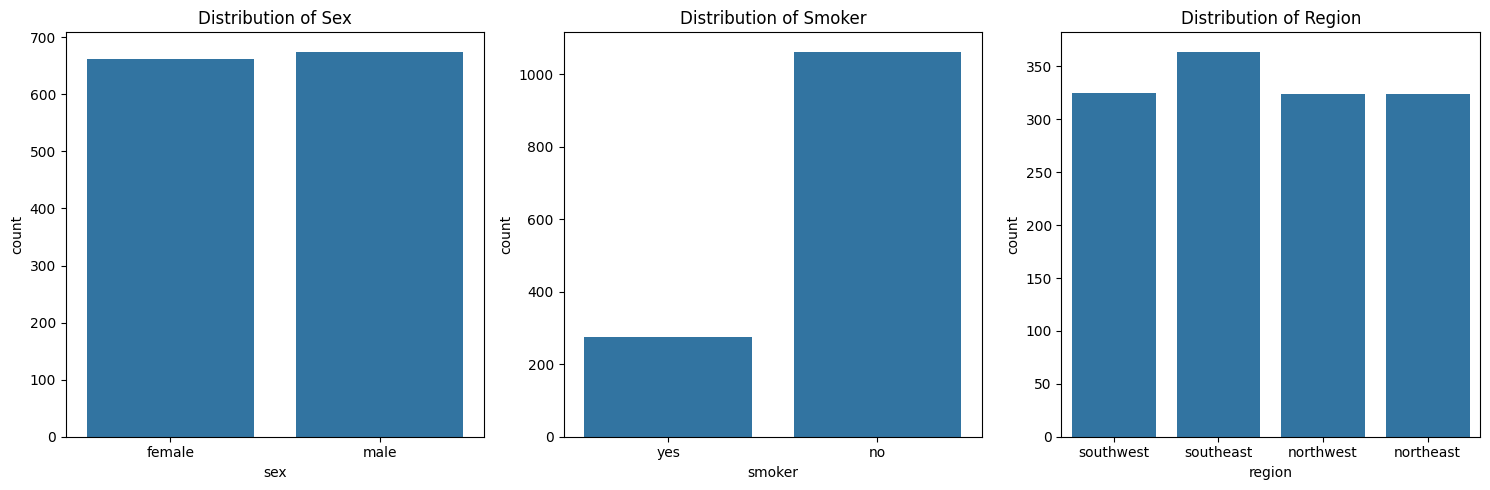

In [65]:
plt.figure(figsize=(15, 5))

# Countplot of 'sex'
plt.subplot(1, 3, 1)
sns.countplot(x='sex', data=data)
plt.title('Distribution of Sex')

# Countplot of 'smoker'
plt.subplot(1, 3, 2)
sns.countplot(x='smoker', data=data)
plt.title('Distribution of Smoker')

# Countplot of 'region'
plt.subplot(1, 3, 3)
sns.countplot(x='region', data=data)
plt.title('Distribution of Region')

plt.tight_layout()
plt.show()


### Observations from Categorical Distributions:
* **Sex:** The gender distribution is **nearly balanced** between males and females.
This indicates that both genders are **almost equally represented** in the dataset, reducing the risk of gender bias in the model.
* **Smoker:** The dataset contains significantly more non-smokers than smokers.
* **Region:** The distribution across the four regions (southeast, southwest, northeast, northwest) is almost even.The Southeast region has the highest number of customers.


## **Bivariate Analysis**

Analyzing relationships between features, especially with the target variable charges.

**Bivariate Analysis (Categorical vs. Charges):**

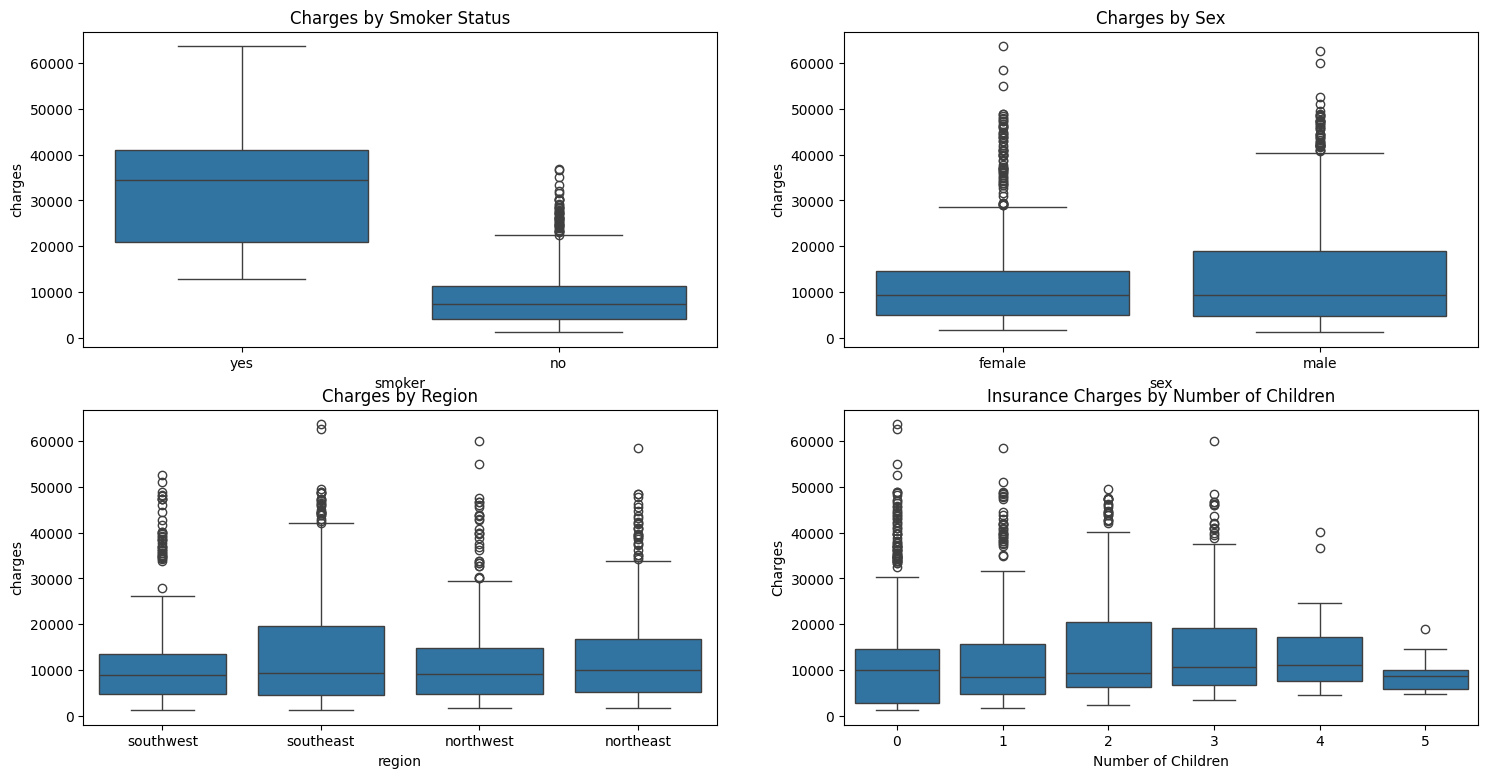

In [66]:
plt.figure(figsize=(18, 9))

# Charges by Smoker Status
plt.subplot(2, 2, 1)
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Charges by Smoker Status')

# Charges by Sex
plt.subplot(2, 2, 2)
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Charges by Sex')

# Charges by Region
plt.subplot(2, 2, 3)
sns.boxplot(x='region', y='charges', data=data)
plt.title('Charges by Region')

# Analyze if the number of children influences charges.
plt.subplot(2, 2, 4)
sns.boxplot(x='children', y='charges', data=data)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()


### Observations from Bivariate Analysis (Categorical vs. Charges):
**Smokers Vs Charges:**
* smokers have much **higher insurance charges** than **non-smokers**.
* The **median charge** for smokers is above **30,000**, while for non-smokers it is below **10,000**.
* Insurance charges for smokers show **greater variation**, indicating higher medical costs.
* This suggests that **smoking status is an important factor affecting insurance charges**.

**Sex vs Charges:**
* Male customers have slightly higher and more varied insurance charges than female customers.
The difference is not very large, but it suggests that gender may have some influence on insurance charges

**Region vs Charges:**
* There are slight differences in charges across regions, with the southeast appearing to have slightly higher average charges, but the difference is not as pronounced as with smoking status.

**Children vs Charges:**
* The box plot shows that insurance charges increase slightly for people with one or two children, but remain relatively stable for three or more children, suggesting that the number of children has only a limited effect on insurance charges.


##Bivariate Analysis (Numerical Vs Smoke)

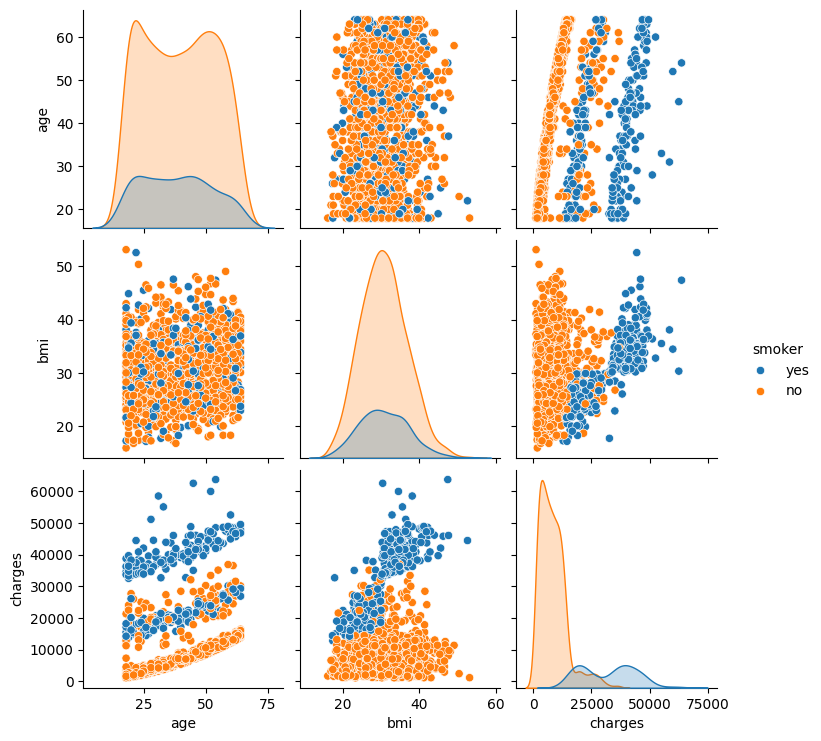

In [67]:
# Create the pair plot
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()


**Observations:**
*  **Smokers vs Non-Smokers**: Smokers have significantly higher insurance charges than non-smokers.
*  **BMI vs Charges**: Insurance charges generally increase with BMI, especially for smokers.
*  **Age vs Charges**: Insurance charges tend to increase with age, particularly among smokers.
*  **Distribution**: Age and BMI distributions are similar for both groups, but smokers have much higher and more spread-out insurance charges.



##**Visualize the numerical columns using a heatmap.**


We check the heatmap to interpret how strongly different features are related to the target variable and identify which factors may influence it the most.


This is a **correlation heatmap**, which shows how strongly numerical variables are related to each other.

- The values range from **-1 to 1**:
  - **1** means a **perfect positive relationship** (as one goes up, the other goes up).
  - **0** means **no relationship**.
  - **-1** means a **perfect negative relationship** (as one goes up, the other goes down).


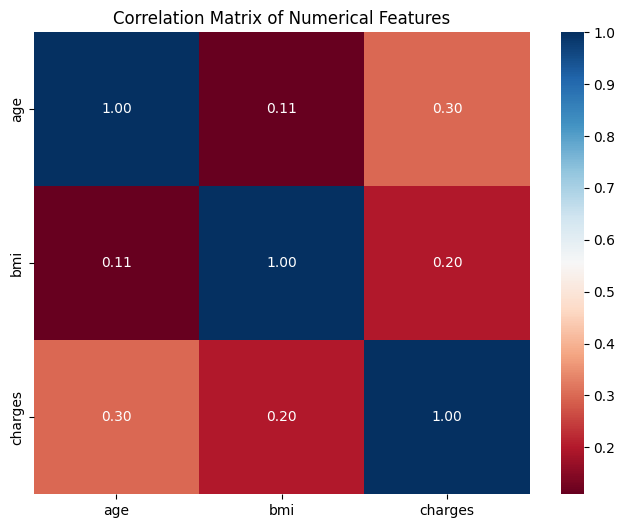

In [68]:
# Create a correlation matrix for numerical features
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


**Observatios:**

- **Age vs Charges (0.30)**:  
   There’s a **moderate positive correlation**. This means that as people get older, their insurance charges tend to increase.

- **BMI vs Charges (0.20)**:  
   There’s a **weak positive correlation**. Higher BMI might lead to higher insurance charges, but the relationship isn't very strong.

- **Age vs BMI (0.11)**:  
   Almost **no correlation** — a person’s age doesn't really tell us much about their BMI.


# **Data Preprocessing**

To predict insurance charges, we build three Linear Regression models:

* Model 1: Uses Age only (Simple Linear Regression).
* Model 2: Uses Age and BMI (Multiple Linear Regression).
* Model 3: Uses all features, including categorical variables.

Before training the third model, the categorical features (sex, smoker, and region) are converted into numerical values using one-hot encoding. The dataset is then split into 70% training data and 30% testing data to evaluate the model's performance on unseen data.
This helps build reliable models and assess their prediction accuracy.


#**Encode the Data**

**NOTE :** We use **dtype=int** in dummy encoding to guarantee that the output is numerical (0 and 1), as it may otherwise default to Boolean values (True and False).

In [69]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)


In [70]:
data.head(10)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
5,31,25.740,0,3756.62160,0,0,0,1,0
6,46,33.440,1,8240.58960,0,0,0,1,0
7,37,27.740,3,7281.50560,0,0,1,0,0
8,37,29.830,2,6406.41070,1,0,0,0,0
9,60,25.840,0,28923.13692,0,0,1,0,0


#**Train Test Split**

In [71]:
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [72]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


The training and testing datasets are properly split, with approximately 70% of the data used for training and 30% for testing.

# **Model Building**

#**Model Evaluation Criterion**

In insurance price prediction, the model can make two types of mistakes:

* **Underestimating the price** – predicting a lower price than the actual value.
* **Overestimating the price** – predicting a higher price than the actual value.

**Underestimating is more critical** because it can cause the insurance company to charge less than required, leading to financial loss.

To make the model more reliable, the goal should be to:

* **Maximize R²** (coefficient of determination), which tells us how well the model explains the variation in prices
* **Minimize MSE** (Mean Squared Error), which measures how close the predictions are to the actual values

A model with high R² and low MSE provides more accurate insurance price predictions.


#**Model Building**

**Linear Regression Model Training**

It is a simple and interpretable algorithm that assumes a linear relationship between the input features and the target variable.

**Model Training**

We train the linear regression model on our training dataset, allowing it to learn the relationship between the independent variables (like age, BMI, smoker status, etc.) and the dependent variable (charges).


In [73]:
# prompt: Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### Model 1

In the first model,using only the `age` feature to demonstrate how simple linear regression works and how it performs.

In [74]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()



<font size=3 color="white"> The linear regression equation.

</font>

In [75]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

Linear Regression Equation: Charges = 3718.81 + (238.82 * Age)


Based on the regression equation, insurance charges increase as the customer's age increases, indicating a positive relationship between age and insurance premium.

Before interpreting the model, it is important to ensure that the assumptions of Linear Regression are satisfied. Finally, we evaluate the model's performance using metrics such as R² and Mean Squared Error (MSE) to measure its prediction accuracy.

In [76]:
#Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results

# Predict on training and testing data
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


- The error is high and the R-squared value is low for both the training and testing datasets, indicating poor model performance and underfitting.
- This is likely due to the use of only a single feature and a simple linear model.

### Model 2

In the second model,using only the numerical features to train a multiple linear regression model, and evaluate how well the model performs.

In [77]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [78]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


Linear Regression Equation: Charges = -3641.79 + (227.40 * Age) + (254.94 * BMI)


Based on the regression equation, insurance charges increase as the customer's BMI increases, while keeping age constant, indicating a positive relationship between BMI and insurance premium.



In [79]:
#Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


- The error has reduced slightly, but is still high, and the R-squared value is low for both the training and testing data, indicating that the model is still performing poorly and **underfitting**.


### Model 3

Now,using the whole dataset, including both numerical and categorical features, to build our multiple linear regression model, and see how the model performs with all available information.

In [80]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [81]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -11516.78 + (251.25 * age) + (328.38 * bmi) + (522.16 * children) + (-111.91 * sex_male) + (22874.45 * smoker_yes) + (-465.75 * region_northwest) + (-936.10 * region_southeast) + (-765.58 * region_southwest)


In [82]:
#Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

## Model 4: Decision Tree Regressor

In [83]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
model_4 = DecisionTreeRegressor(random_state=42)
model_4.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [84]:
# Evaluate the Decision Tree model's performance.
# Predict on training and testing data
y_train_pred_m4 = model_4.predict(X_train)
y_test_pred_m4 = model_4.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m4 = mean_squared_error(y_train, y_train_pred_m4)
train_r2_m4 = r2_score(y_train, y_train_pred_m4)

# Calculate MSE and R2 for testing data
test_mse_m4 = mean_squared_error(y_test, y_test_pred_m4)
test_r2_m4 = r2_score(y_test, y_test_pred_m4)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 4 (Decision Tree)', train_mse_m4, train_r2_m4, test_mse_m4, test_r2_m4]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436
3,Model 4 (Decision Tree),0.000000e+00,1.000000,3.849066e+07,0.775063


## Model Comparison and Final Model Selection


*   **Model 1 (Age Only)** and **Model 2 (Age and BMI)** show very low R-squared and high MSE, indicating poor performance.
*   **Model 3 (All Features)** shows a significant improvement in both R-squared and MSE on both train and test sets, suggesting good generalization, providing the best prediction accuracy.
*   **Model 4 (Decision Tree)** perfectly fits the training data (R2=1.0, MSE=0.0) but has similar test performance to Model 3, confirming the overfitting on the training data previously discussed.

Therefore, **Model 3** is selected as the **final model** because it uses all available features and delivers the **best overall performance.**

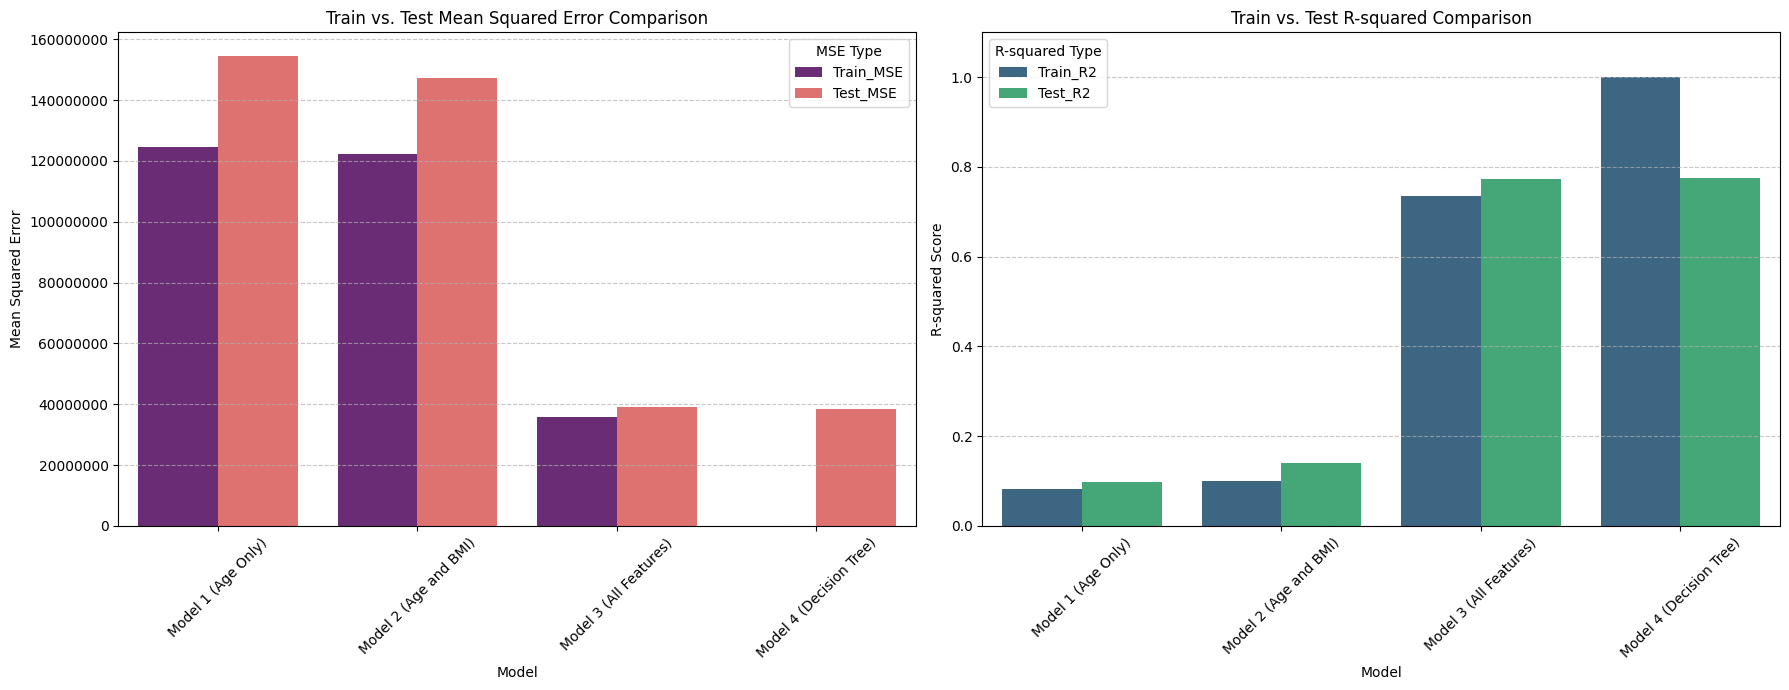

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
mse_melted = model_eval_results.melt(id_vars='Model', value_vars=['Train_MSE', 'Test_MSE'], var_name='MSE_Type', value_name='MSE_Score')
r2_melted = model_eval_results.melt(id_vars='Model', value_vars=['Train_R2', 'Test_R2'], var_name='R2_Type', value_name='R2_Score')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for MSE
sns.barplot(x='Model', y='MSE_Score', hue='MSE_Type', data=mse_melted, ax=axes[0], palette='magma')
axes[0].set_title('Train vs. Test Mean Squared Error Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Mean Squared Error')
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='MSE Type')
axes[0].tick_params(axis='x', rotation=45)

# Plot for R-squared
sns.barplot(x='Model', y='R2_Score', hue='R2_Type', data=r2_melted, ax=axes[1], palette='viridis')
axes[1].set_title('Train vs. Test R-squared Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R-squared Score')
axes[1].set_ylim(0, 1.1) # R-squared values are typically between 0 and 1
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='R-squared Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Predicting Charges for New, Unseen Data


Now, let's use Model 3 to predict charges for this encoded new data.

In [86]:
new_data_predictions = model_3.predict(X_test[3:10])
new_data_predictions

array([31428.2037203 ,  8874.78160711, 13108.23558267, 30222.44619694,
        1224.76010921, 10576.43395847, 11204.40476605])

In [87]:
y_test[3:10]

,charges
298,38746.3551
237,4463.2051
481,9304.7019
240,38511.6283
277,2150.4690
415,7345.7266
707,10264.4421


# **Business Recommendation**

1. **Targeted Premium Pricing**: Adjust insurance premiums based on age and BMI to better reflect customer risk.

2. **Smoking Cessation Incentives**  
   Offer discounts or wellness rewards to encourage non-smoking behavior and reduce insurance costs.
3. **Wellness Programs**  
   Promote healthy lifestyle and BMI management to lower health risks and future claims.
4. **Region-Based Strategy**  
   Since region has a limited impact, use region-specific pricing only if supported by operational or risk differences.
5. **Marketing Focus**  
   Focus on younger individuals, non-smokers, and customers with a healthy BMI for affordable plans, while providing suitable coverage options for higher-risk customers.

<font size=6 color="navyblue">Power Ahead!</font>
___